In [1]:
import os
import sys

In [2]:
# this adds the module to the path so that it can be used to call the functions
root = os.path.abspath(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(root)

In [3]:
from src.classes import Node, Cirq_Tableau
from src.heuristic_module import pair_solve
from src.mcts_module import full_circuit, p_word_solution, cx_count

In [4]:
from qiskit.circuit import QuantumCircuit

In [5]:
TIME = 10 # time parameter for tree search in seconds 
PARAM = 10 # UCT parameter

## *Test Data*

In [6]:
ucc_2_4 = [
    [
        "YZXI",
        "XZXI",
        "YZYI",
        "XZYI"
    ],
    [
        "IYZX",
        "IXZX",
        "IYZY",
        "IXZY"
    ],
    [
        "YXYX",
        "XXYX",
        "YYYX",
        "XYYX",
        "YXYY",
        "XXYY",
        "YYYY",
        "XYYY",
        "YXXX",
        "XXXX",
        "YYXX",
        "XYXX",
        "YXXY",
        "XXXY",
        "YYXY",
        "XYXY"
    ]
]

ucc_2_6 = [
    [
        "YZXIII",
        "XZXIII",
        "YZYIII",
        "XZYIII"
    ],
    [
        "YZZZXI",
        "XZZZXI",
        "YZZZYI",
        "XZZZYI"
    ],
    [
        "IYZXII",
        "IXZXII",
        "IYZYII",
        "IXZYII"
    ],
    [
        "IYZZZX",
        "IXZZZX",
        "IYZZZY",
        "IXZZZY"
    ],
    [
        "YXYXII",
        "XXYXII",
        "YYYXII",
        "XYYXII",
        "YXYYII",
        "XXYYII",
        "YYYYII",
        "XYYYII",
        "YXXXII",
        "XXXXII",
        "YYXXII",
        "XYXXII",
        "YXXYII",
        "XXXYII",
        "YYXYII",
        "XYXYII"
    ],
    [
        "YXYZZX",
        "XXYZZX",
        "YYYZZX",
        "XYYZZX",
        "YXYZZY",
        "XXYZZY",
        "YYYZZY",
        "XYYZZY",
        "YXXZZX",
        "XXXZZX",
        "YYXZZX",
        "XYXZZX",
        "YXXZZY",
        "XXXZZY",
        "YYXZZY",
        "XYXZZY"
    ],
    [
        "YXIYXI",
        "XXIYXI",
        "YYIYXI",
        "XYIYXI",
        "YXIYYI",
        "XXIYYI",
        "YYIYYI",
        "XYIYYI",
        "YXIXXI",
        "XXIXXI",
        "YYIXXI",
        "XYIXXI",
        "YXIXYI",
        "XXIXYI",
        "YYIXYI",
        "XYIXYI"
    ],
    [
        "YXIIYX",
        "XXIIYX",
        "YYIIYX",
        "XYIIYX",
        "YXIIYY",
        "XXIIYY",
        "YYIIYY",
        "XYIIYY",
        "YXIIXX",
        "XXIIXX",
        "YYIIXX",
        "XYIIXX",
        "YXIIXY",
        "XXIIXY",
        "YYIIXY",
        "XYIIXY"
    ]
]

ucc_4_8 = [
    [
        "YZZZXIII",
        "XZZZXIII",
        "YZZZYIII",
        "XZZZYIII"
    ],
    [
        "YZZZZZXI",
        "XZZZZZXI",
        "YZZZZZYI",
        "XZZZZZYI"
    ],
    [
        "IYZZZXII",
        "IXZZZXII",
        "IYZZZYII",
        "IXZZZYII"
    ],
    [
        "IYZZZZZX",
        "IXZZZZZX",
        "IYZZZZZY",
        "IXZZZZZY"
    ],
    [
        "IIYZXIII",
        "IIXZXIII",
        "IIYZYIII",
        "IIXZYIII"
    ],
    [
        "IIYZZZXI",
        "IIXZZZXI",
        "IIYZZZYI",
        "IIXZZZYI"
    ],
    [
        "IIIYZXII",
        "IIIXZXII",
        "IIIYZYII",
        "IIIXZYII"
    ],
    [
        "IIIYZZZX",
        "IIIXZZZX",
        "IIIYZZZY",
        "IIIXZZZY"
    ],
    [
        "YXIIYXII",
        "XXIIYXII",
        "YYIIYXII",
        "XYIIYXII",
        "YXIIYYII",
        "XXIIYYII",
        "YYIIYYII",
        "XYIIYYII",
        "YXIIXXII",
        "XXIIXXII",
        "YYIIXXII",
        "XYIIXXII",
        "YXIIXYII",
        "XXIIXYII",
        "YYIIXYII",
        "XYIIXYII"
    ],
    [
        "YXIIYZZX",
        "XXIIYZZX",
        "YYIIYZZX",
        "XYIIYZZX",
        "YXIIYZZY",
        "XXIIYZZY",
        "YYIIYZZY",
        "XYIIYZZY",
        "YXIIXZZX",
        "XXIIXZZX",
        "YYIIXZZX",
        "XYIIXZZX",
        "YXIIXZZY",
        "XXIIXZZY",
        "YYIIXZZY",
        "XYIIXZZY"
    ],
    [
        "YXIIIYXI",
        "XXIIIYXI",
        "YYIIIYXI",
        "XYIIIYXI",
        "YXIIIYYI",
        "XXIIIYYI",
        "YYIIIYYI",
        "XYIIIYYI",
        "YXIIIXXI",
        "XXIIIXXI",
        "YYIIIXXI",
        "XYIIIXXI",
        "YXIIIXYI",
        "XXIIIXYI",
        "YYIIIXYI",
        "XYIIIXYI"
    ],
    [
        "YXIIIIYX",
        "XXIIIIYX",
        "YYIIIIYX",
        "XYIIIIYX",
        "YXIIIIYY",
        "XXIIIIYY",
        "YYIIIIYY",
        "XYIIIIYY",
        "YXIIIIXX",
        "XXIIIIXX",
        "YYIIIIXX",
        "XYIIIIXX",
        "YXIIIIXY",
        "XXIIIIXY",
        "YYIIIIXY",
        "XYIIIIXY"
    ],
    [
        "YZXIYZXI",
        "XZXIYZXI",
        "YZYIYZXI",
        "XZYIYZXI",
        "YZXIYZYI",
        "XZXIYZYI",
        "YZYIYZYI",
        "XZYIYZYI",
        "YZXIXZXI",
        "XZXIXZXI",
        "YZYIXZXI",
        "XZYIXZXI",
        "YZXIXZYI",
        "XZXIXZYI",
        "YZYIXZYI",
        "XZYIXZYI"
    ],
    [
        "YZZXYXII",
        "XZZXYXII",
        "YZZYYXII",
        "XZZYYXII",
        "YZZXYYII",
        "XZZXYYII",
        "YZZYYYII",
        "XZZYYYII",
        "YZZXXXII",
        "XZZXXXII",
        "YZZYXXII",
        "XZZYXXII",
        "YZZXXYII",
        "XZZXXYII",
        "YZZYXYII",
        "XZZYXYII"
    ],
    [
        "YZZXYZZX",
        "XZZXYZZX",
        "YZZYYZZX",
        "XZZYYZZX",
        "YZZXYZZY",
        "XZZXYZZY",
        "YZZYYZZY",
        "XZZYYZZY",
        "YZZXXZZX",
        "XZZXXZZX",
        "YZZYXZZX",
        "XZZYXZZX",
        "YZZXXZZY",
        "XZZXXZZY",
        "YZZYXZZY",
        "XZZYXZZY"
    ],
    [
        "YZZXIYXI",
        "XZZXIYXI",
        "YZZYIYXI",
        "XZZYIYXI",
        "YZZXIYYI",
        "XZZXIYYI",
        "YZZYIYYI",
        "XZZYIYYI",
        "YZZXIXXI",
        "XZZXIXXI",
        "YZZYIXXI",
        "XZZYIXXI",
        "YZZXIXYI",
        "XZZXIXYI",
        "YZZYIXYI",
        "XZZYIXYI"
    ],
    [
        "YZZXIIYX",
        "XZZXIIYX",
        "YZZYIIYX",
        "XZZYIIYX",
        "YZZXIIYY",
        "XZZXIIYY",
        "YZZYIIYY",
        "XZZYIIYY",
        "YZZXIIXX",
        "XZZXIIXX",
        "YZZYIIXX",
        "XZZYIIXX",
        "YZZXIIXY",
        "XZZXIIXY",
        "YZZYIIXY",
        "XZZYIIXY"
    ],
    [
        "IYXIYXII",
        "IXXIYXII",
        "IYYIYXII",
        "IXYIYXII",
        "IYXIYYII",
        "IXXIYYII",
        "IYYIYYII",
        "IXYIYYII",
        "IYXIXXII",
        "IXXIXXII",
        "IYYIXXII",
        "IXYIXXII",
        "IYXIXYII",
        "IXXIXYII",
        "IYYIXYII",
        "IXYIXYII"
    ],
    [
        "IYXIYZZX",
        "IXXIYZZX",
        "IYYIYZZX",
        "IXYIYZZX",
        "IYXIYZZY",
        "IXXIYZZY",
        "IYYIYZZY",
        "IXYIYZZY",
        "IYXIXZZX",
        "IXXIXZZX",
        "IYYIXZZX",
        "IXYIXZZX",
        "IYXIXZZY",
        "IXXIXZZY",
        "IYYIXZZY",
        "IXYIXZZY"
    ],
    [
        "IYXIIYXI",
        "IXXIIYXI",
        "IYYIIYXI",
        "IXYIIYXI",
        "IYXIIYYI",
        "IXXIIYYI",
        "IYYIIYYI",
        "IXYIIYYI",
        "IYXIIXXI",
        "IXXIIXXI",
        "IYYIIXXI",
        "IXYIIXXI",
        "IYXIIXYI",
        "IXXIIXYI",
        "IYYIIXYI",
        "IXYIIXYI"
    ],
    [
        "IYXIIIYX",
        "IXXIIIYX",
        "IYYIIIYX",
        "IXYIIIYX",
        "IYXIIIYY",
        "IXXIIIYY",
        "IYYIIIYY",
        "IXYIIIYY",
        "IYXIIIXX",
        "IXXIIIXX",
        "IYYIIIXX",
        "IXYIIIXX",
        "IYXIIIXY",
        "IXXIIIXY",
        "IYYIIIXY",
        "IXYIIIXY"
    ],
    [
        "IYZXIYZX",
        "IXZXIYZX",
        "IYZYIYZX",
        "IXZYIYZX",
        "IYZXIYZY",
        "IXZXIYZY",
        "IYZYIYZY",
        "IXZYIYZY",
        "IYZXIXZX",
        "IXZXIXZX",
        "IYZYIXZX",
        "IXZYIXZX",
        "IYZXIXZY",
        "IXZXIXZY",
        "IYZYIXZY",
        "IXZYIXZY"
    ],
    [
        "IIYXYXII",
        "IIXXYXII",
        "IIYYYXII",
        "IIXYYXII",
        "IIYXYYII",
        "IIXXYYII",
        "IIYYYYII",
        "IIXYYYII",
        "IIYXXXII",
        "IIXXXXII",
        "IIYYXXII",
        "IIXYXXII",
        "IIYXXYII",
        "IIXXXYII",
        "IIYYXYII",
        "IIXYXYII"
    ],
    [
        "IIYXYZZX",
        "IIXXYZZX",
        "IIYYYZZX",
        "IIXYYZZX",
        "IIYXYZZY",
        "IIXXYZZY",
        "IIYYYZZY",
        "IIXYYZZY",
        "IIYXXZZX",
        "IIXXXZZX",
        "IIYYXZZX",
        "IIXYXZZX",
        "IIYXXZZY",
        "IIXXXZZY",
        "IIYYXZZY",
        "IIXYXZZY"
    ],
    [
        "IIYXIYXI",
        "IIXXIYXI",
        "IIYYIYXI",
        "IIXYIYXI",
        "IIYXIYYI",
        "IIXXIYYI",
        "IIYYIYYI",
        "IIXYIYYI",
        "IIYXIXXI",
        "IIXXIXXI",
        "IIYYIXXI",
        "IIXYIXXI",
        "IIYXIXYI",
        "IIXXIXYI",
        "IIYYIXYI",
        "IIXYIXYI"
    ],
    [
        "IIYXIIYX",
        "IIXXIIYX",
        "IIYYIIYX",
        "IIXYIIYX",
        "IIYXIIYY",
        "IIXXIIYY",
        "IIYYIIYY",
        "IIXYIIYY",
        "IIYXIIXX",
        "IIXXIIXX",
        "IIYYIIXX",
        "IIXYIIXX",
        "IIYXIIXY",
        "IIXXIIXY",
        "IIYYIIXY",
        "IIXYIIXY"
    ]
]

## *Tests*

In [7]:
pauli_word = Cirq_Tableau(ucc_2_4[2]) # Tableau form of a Pauli word 
solution = p_word_solution(pauli_word, pair_solve, PARAM, TIME)
solution

[('CX', 0, 1),
 ('CX', 0, 2),
 ('S', 0),
 ('S', 3),
 ('CX', 0, 3),
 ('X', 0),
 ('-Y', 0),
 ('H', 1),
 ('CX', 0, 1),
 ('Y', 0),
 ('X', 0),
 ('S', 0),
 ('H', 3),
 ('CX', 0, 3),
 ('Y', 0),
 ('X', 0),
 ('CX', 0, 1),
 ('X', 0),
 ('-Y', 0),
 ('H', 2),
 ('CX', 0, 2),
 ('Y', 0),
 ('X', 0),
 ('CX', 0, 1),
 ('-X', 0),
 ('Y', 0),
 ('CX', 0, 3),
 ('-Y', 0),
 ('-X', 0),
 ('CX', 0, 1),
 ('-X', 0),
 ('Y', 0)]

In [8]:
cx_count(solution)

10

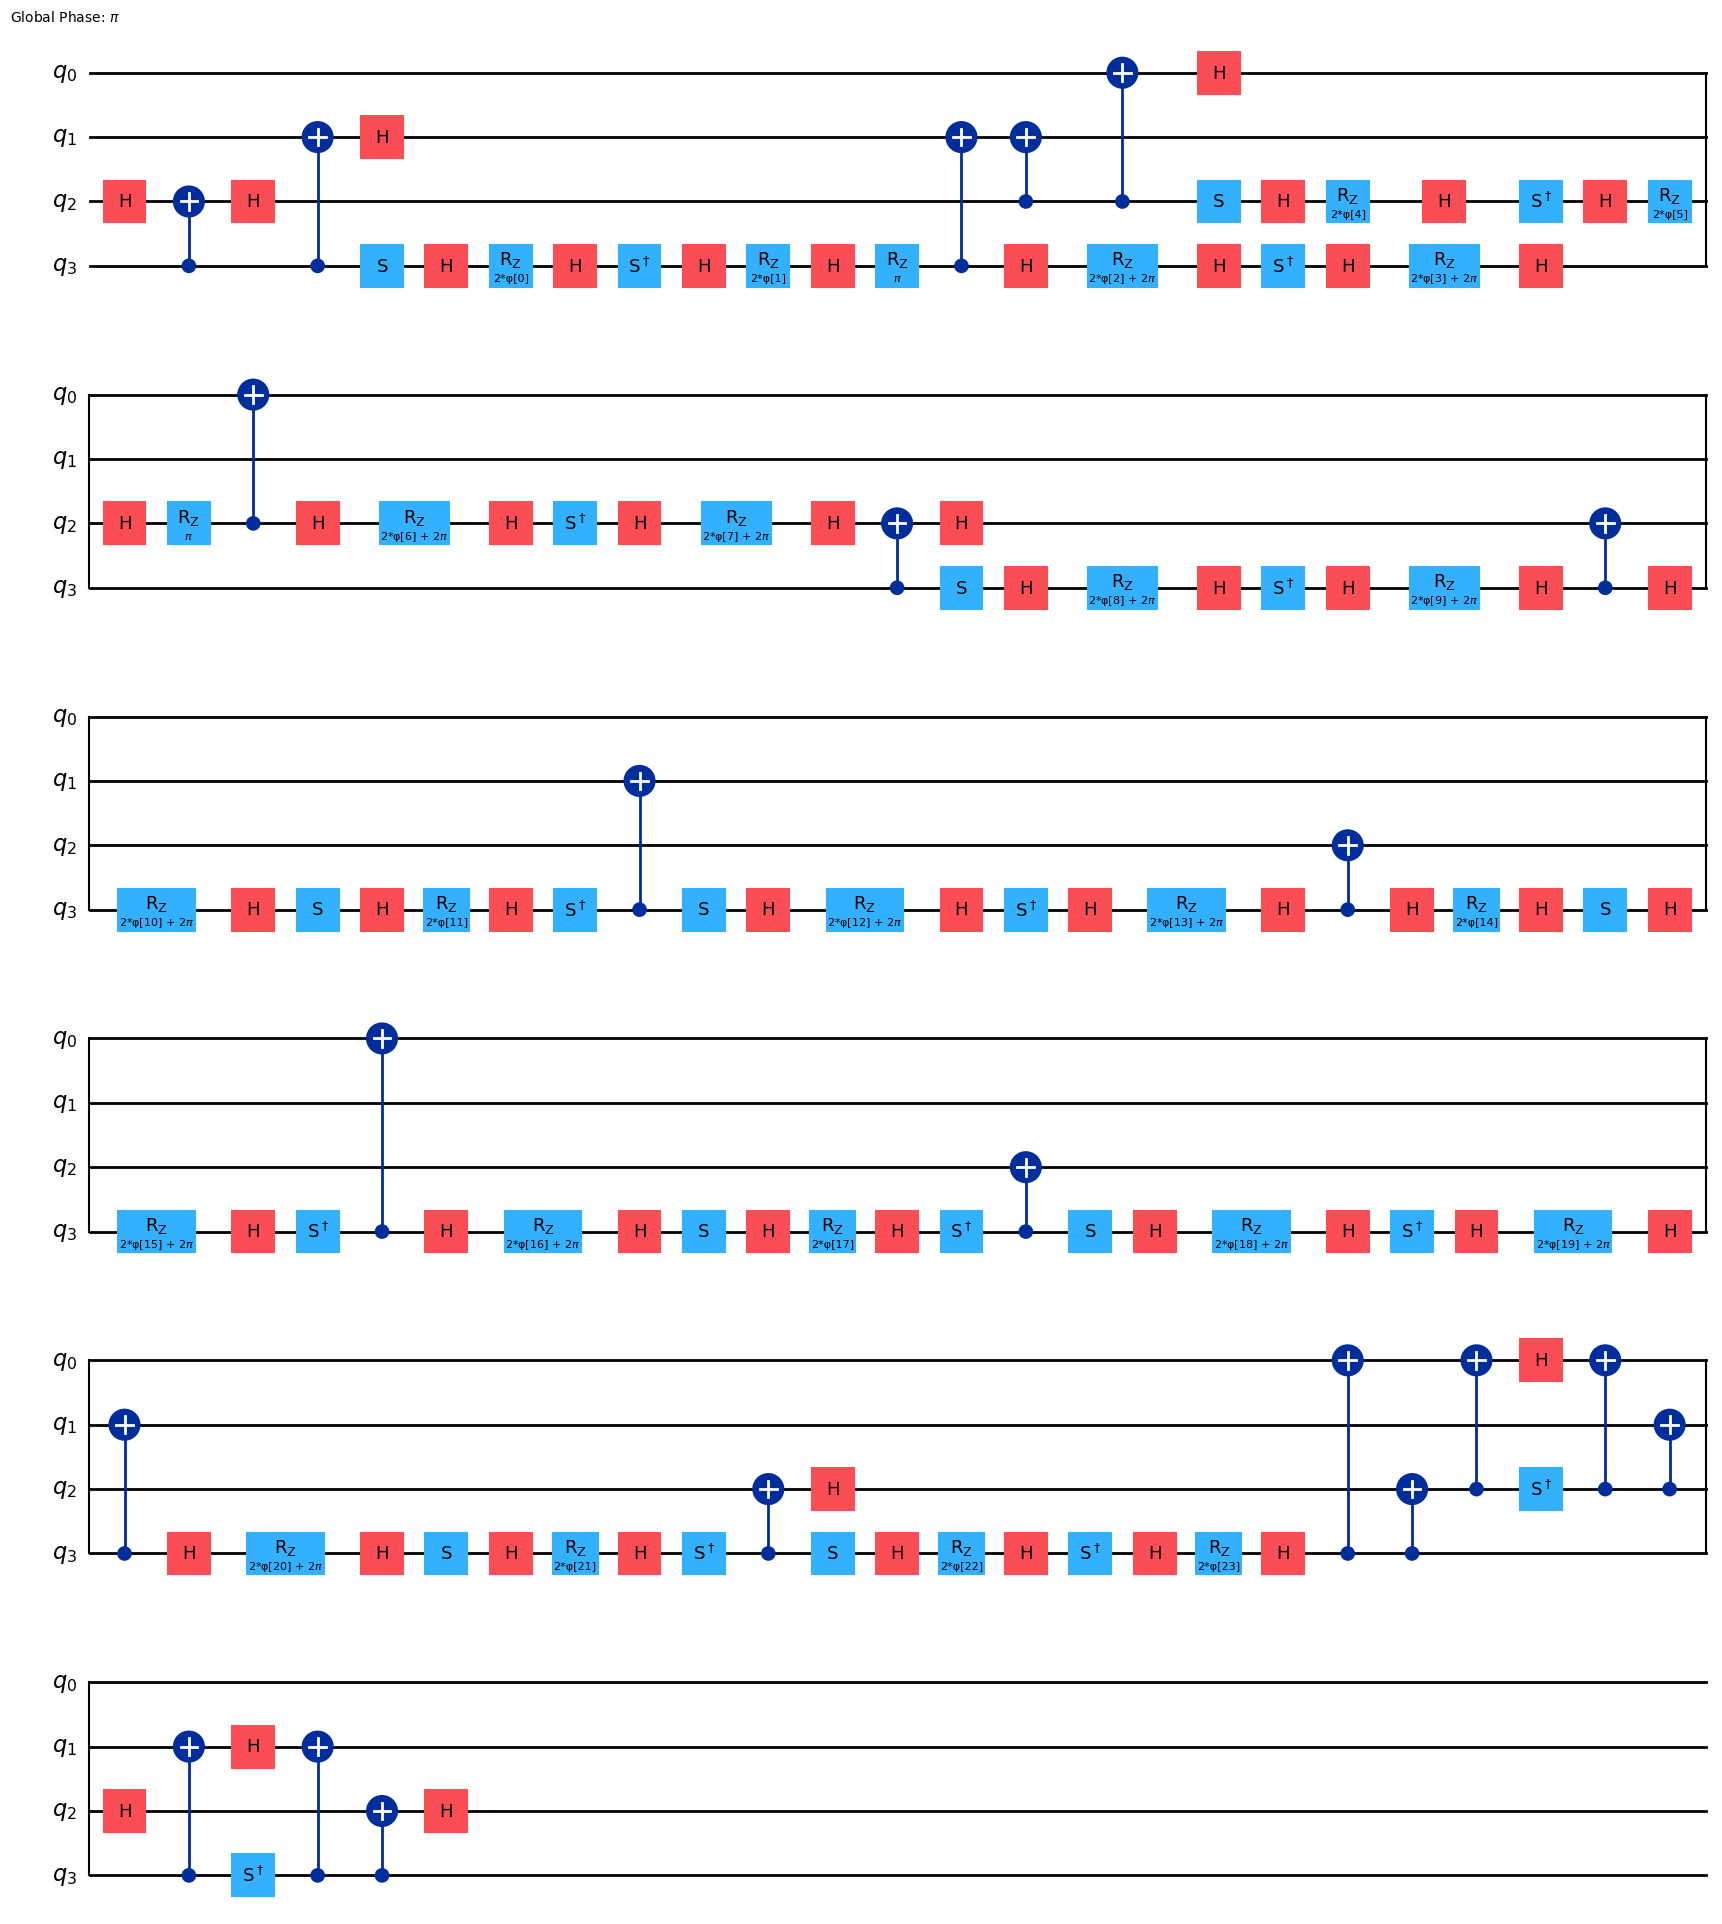

In [7]:
circuit = full_circuit(ucc_2_4, pair_solve, PARAM, TIME, gate_cancellation=True)
circuit.draw('mpl')

In [8]:
circuit.count_ops()['cx']

22